In [1]:
from adversial import adversial_model
from adversial import gen_adv_seq
from evaluate import eval_adv
from Algorithms.EXP3 import EXP3_policy
import numpy as np
import matplotlib.pyplot as plt

adv_rng = np.random.default_rng(500)
my_rng = np.random.default_rng(123)

horizon = 100000
c1 = 0.98
c2 = 0.98

model_data = {
    0: [str(i) for i in gen_adv_seq(adv_rng, horizon, c=c1)], # Arm 0
    1: [str(i) for i in gen_adv_seq(adv_rng, horizon, c=c2)], # Arm 1 (Control: purely random)
}

gamma = min(1, np.sqrt( (2 * np.log(2)) / ((np.e - 1) * horizon) ))
model = adversial_model(' '.join(model_data[0]), ' '.join(model_data[1]))
policy = EXP3_policy(model, my_rng, gamma=0.1)

res = eval_adv(model, policy)

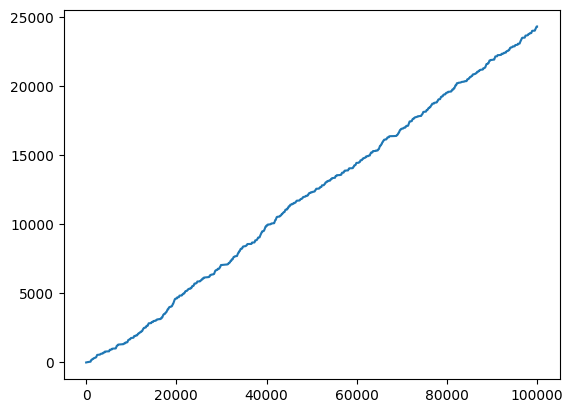

In [2]:
plt.plot(res)